In [1]:
import numpy as np
from PIL import Image
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-03-04 09:06:59.562759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772615219.792056      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772615219.852162      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772615220.370943      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772615220.370981      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772615220.370983      55 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
base = '/kaggle/input/datasets/orvile/macular-degeneration-disease-dataset/AMDNet23 Fundus Image Dataset for Age-Related Macular Degeneration Disease Detection/AMDNet23 Fundus Image Dataset for  Age-Related Macular Degeneration Disease Detection/AMDNet23 Dataset/'

train_dir = os.path.join(base, 'train')
val_dir   = os.path.join(base, 'valid')

odir_amd  = '/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/ageDegeneration'

for cls in ['amd', 'normal']:
    print(f"{cls} — train: {len(os.listdir(os.path.join(train_dir, cls)))}, val: {len(os.listdir(os.path.join(val_dir, cls)))}")
print(f"ODIR AMD: {len(os.listdir(odir_amd))}")

amd — train: 394, val: 100
normal — train: 400, val: 100
ODIR AMD: 266


In [14]:
def preprocess(img_path, img_size=(224, 224)):
    img = Image.open(img_path).convert('RGB')
    
    # Center crop to square first — no squishing
    w, h = img.size
    min_dim = min(w, h)
    left = (w - min_dim) // 2
    top  = (h - min_dim) // 2
    img  = img.crop((left, top, left + min_dim, top + min_dim))
    
    # Now resize to 224x224 — perfect square, no distortion
    img  = img.resize(img_size)
    img_array = np.array(img, dtype=np.uint8)
    
    # Grayscale
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Stack to 3 channels
    img_3ch = np.stack([enhanced]*3, axis=-1)
    return img_3ch.astype(np.float32)

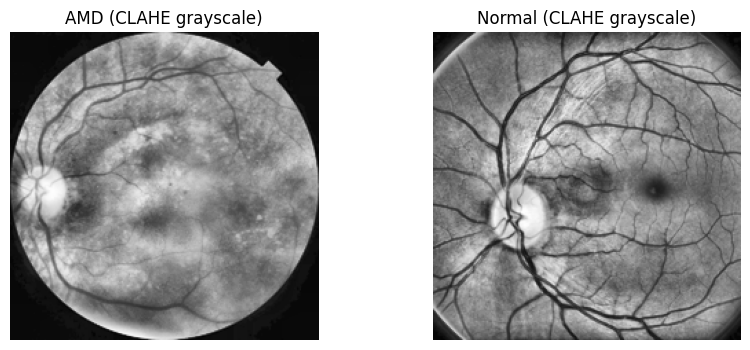

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(X_train[0].astype(np.uint8), cmap='gray')
axes[0].set_title('AMD (CLAHE grayscale)')
axes[0].axis('off')
axes[1].imshow(X_train[660].astype(np.uint8), cmap='gray')
axes[1].set_title('Normal (CLAHE grayscale)')
axes[1].axis('off')
plt.show()

In [16]:
print("Reloading AMD...")
amd_imgs,    amd_lbls    = load_folder(os.path.join(train_dir, 'amd'),    label=0)
print("Reloading ODIR AMD...")
odir_imgs,   odir_lbls   = load_folder(odir_amd,                          label=0)
print("Reloading Normal...")
normal_imgs, normal_lbls = load_folder(os.path.join(train_dir, 'normal'), label=1)
print("Reloading ODIR Normal...")
odir_normal_imgs, odir_normal_lbls = load_folder(odir_normal, label=1, max_images=266)

print("Reloading validation...")
val_amd_imgs,    val_amd_lbls    = load_folder(os.path.join(val_dir, 'amd'),    label=0)
val_normal_imgs, val_normal_lbls = load_folder(os.path.join(val_dir, 'normal'), label=1)

X_train = np.array(amd_imgs + odir_imgs + normal_imgs + odir_normal_imgs, dtype=np.float32)
y_train = np.array(amd_lbls + odir_lbls + normal_lbls + odir_normal_lbls, dtype=np.int32)

X_val = np.array(val_amd_imgs + val_normal_imgs, dtype=np.float32)
y_val = np.array(val_amd_lbls + val_normal_lbls, dtype=np.int32)

print(f"Total: {X_train.shape}")

Reloading AMD...
Reloading ODIR AMD...
Reloading Normal...
Reloading ODIR Normal...
Reloading validation...
Total: (1326, 224, 224, 3)


In [18]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(256, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model   = tf.keras.Model(inputs, outputs)
model.summary()

I0000 00:00:1772616568.605029      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772616568.611185      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))

Train batches: 42
Val batches: 7


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

print("Training done!")

Epoch 1/30


I0000 00:00:1772616677.911632     171 service.cc:152] XLA service 0x7d2d40115920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772616677.911671     171 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772616677.911675     171 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772616680.098212     171 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-04 09:31:26.799451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:26.942667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:27.281181: E external/local_xl

40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6976 - loss: 0.5662

2026-03-04 09:31:42.371515: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:42.509800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:42.821341: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:42.961097: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:31:43.658365: E external/local_xla/xla/stream_

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7004 - loss: 0.5622

2026-03-04 09:32:00.462845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:32:00.598074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:32:00.902138: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:32:01.045783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 09:32:01.185661: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.14512, saving model to /kaggle/working/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 765ms/step - accuracy: 0.7017 - loss: 0.5603 - val_accuracy: 0.9500 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8074 - loss: 0.4002
Epoch 2: val_loss improved from 0.14512 to 0.12737, saving model to /kaggle/working/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8079 - loss: 0.3995 - val_accuracy: 0.9700 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 3/30
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8466 - loss: 0.3297
Epoch 3: val_loss improved from 0.12737 to 0.09986, saving model to /kaggle/working/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8465 - loss: 0.3298 - val_accuracy: 0.9850 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 4/30
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8882 - loss: 0.2847
Epoch 4: val_loss impro

In [21]:
model.save('/kaggle/working/amd_fundus_model.keras')
print("Model saved!")

Model saved!


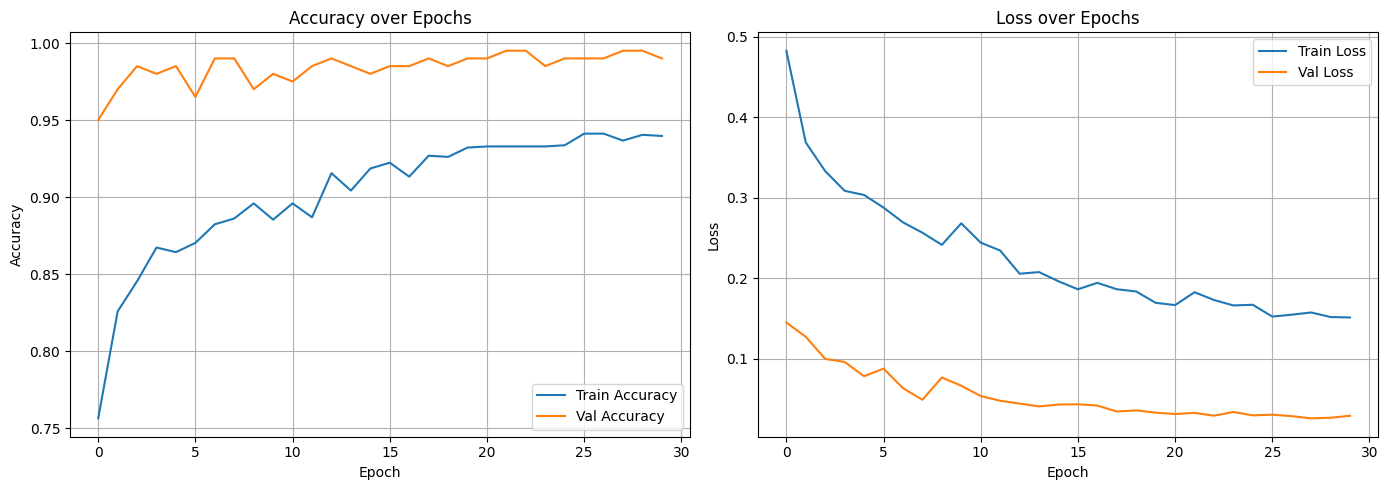

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()